In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## 🔹 Data Preparation

#### 1.  Load the dataset and display first 5 rows.



In [12]:
df = pd.read_csv("customer_satisfaction_data_2.csv")
print(df.head())


   Survey_ID Customer_ID Store_Location  Visit_Date  Purchase_Amount  \
0          1     CUST001          Surat  2026-06-13          3843.49   
1          2     CUST002         Mumbai  2026-08-04          5907.79   
2          3     CUST003          Surat  2026-02-11           963.91   
3          4     CUST004           Pune  2026-06-10          1695.15   
4          5     CUST005           Pune  2026-09-20          4837.22   

   Wait_Time_Min  Staff_Rating  Product_Rating  Cleanliness_Rating Recommend  \
0             33             1               2                   5        No   
1             32             5               4                   2        No   
2              7             4               1                   4        No   
3             17             3               3                   4        No   
4             22             1               5                   5       Yes   

   Total_Rating  
0          2.67  
1          3.67  
2          3.00  
3          3.3

#### 2.  Convert Visit_Date into datetime format and extract Month and Weekday.

In [13]:
print(df.dtypes)

df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])

df['Month'] = df['Visit_Date'].dt.month_name()

df['Weekday'] = df['Visit_Date'].dt.day_name()

print(df[['Visit_Date', "Month" , "Weekday"]].head())

Survey_ID               int64
Customer_ID               str
Store_Location            str
Visit_Date                str
Purchase_Amount       float64
Wait_Time_Min           int64
Staff_Rating            int64
Product_Rating          int64
Cleanliness_Rating      int64
Recommend                 str
Total_Rating          float64
dtype: object
  Visit_Date      Month    Weekday
0 2026-06-13       June   Saturday
1 2026-08-04     August    Tuesday
2 2026-02-11   February  Wednesday
3 2026-06-10       June  Wednesday
4 2026-09-20  September     Sunday


#### 3.  Replace ratings (1-5) with descriptive categories using NumPy/Pandas (Low, Medium, High).

In [14]:
def rating_calculation(rating):
  if rating <= 2:
    return 'Low'
  elif rating == 3:
    return 'Medium'
  else:
    return 'High'

df['Staff_Rating_Calculation'] = df['Staff_Rating'].apply(rating_calculation)
df['Product_Rating_Calculation'] = df['Product_Rating'].apply(rating_calculation)
df['Cleanliness_Rating_Calculation'] = df['Cleanliness_Rating'].apply(rating_calculation)

print(df[[
  "Staff_Rating",
  "Staff_Rating_Calculation",
  "Product_Rating",
  "Product_Rating_Calculation",
  "Cleanliness_Rating",
  "Cleanliness_Rating_Calculation"
]].head())


   Staff_Rating Staff_Rating_Calculation  Product_Rating  \
0             1                      Low               2   
1             5                     High               4   
2             4                     High               1   
3             3                   Medium               3   
4             1                      Low               5   

  Product_Rating_Calculation  Cleanliness_Rating  \
0                        Low                   5   
1                       High                   2   
2                        Low                   4   
3                     Medium                   4   
4                       High                   5   

  Cleanliness_Rating_Calculation  
0                           High  
1                            Low  
2                           High  
3                           High  
4                           High  


#### 4.  Calculate average Total_Rating by Store_Location.

In [15]:
location_rating = df.groupby('Store_Location')['Total_Rating'].mean()

print(location_rating)

Store_Location
Ahmedabad    3.098889
Mumbai       2.845357
Pune         2.896923
Rajkot       2.965263
Surat        2.902917
Vadodara     3.153462
Name: Total_Rating, dtype: float64


#### 5.  Analyze the correlation between Wait_Time_Min and Purchase_Amount.


In [16]:
correlation = np.corrcoef(df['Wait_Time_Min'] , df['Purchase_Amount'])[0 , 1]

print("Correlation:" , round(correlation , 2))

Correlation: -0.05


####  6.  Find which day of the week has highest total purchases.


In [17]:
day_purchase = df.groupby("Weekday")["Purchase_Amount"].sum()

highest_day = day_purchase.idxmax()

highest_amount = day_purchase.max()

print("Day :" , highest_day)

print("Amount :" , highest_amount)

Day : Thursday
Amount : 105511.51000000001


#### 7.  Determine how many customers recommend the store from each location.

In [18]:
recommendation = df[df['Recommend'] == "Yes"].groupby(["Store_Location"]).size()

print(recommendation)

Store_Location
Ahmedabad    4
Pune         3
Rajkot       3
Surat        5
Vadodara     5
dtype: int64


#### 8.  Plot a bar chart of average ratings by store location.


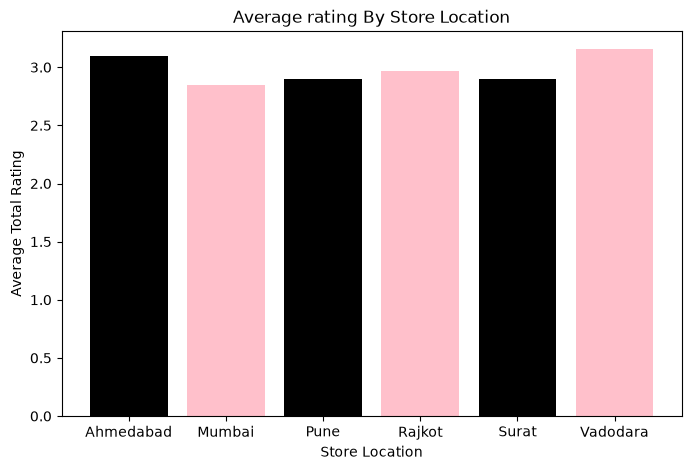

In [19]:
plt.figure(figsize=(8,5))
plt.bar(
    location_rating.index,
    location_rating.values,
    color=("black" , "pink" , )
)
plt.title("Average rating By Store Location")

plt.xlabel("Store Location")

plt.ylabel("Average Total Rating")

plt.show()

#### 9.  Create a pie chart for recommendation distribution.


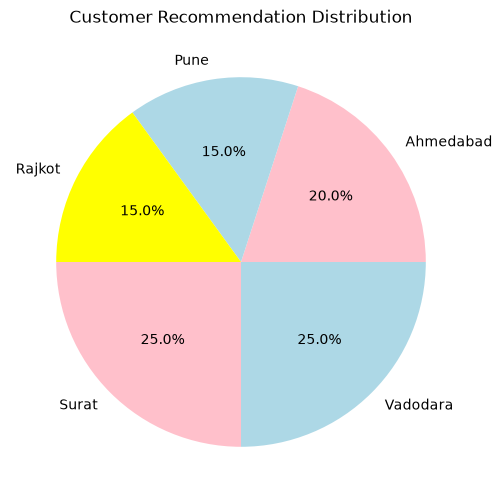

In [20]:
plt.figure(figsize=(6 , 6))

plt.pie(
  recommendation.values,
  labels=recommendation.index,
  autopct="%1.1f%%",
  colors=("pink","lightblue","yellow")
)
plt.title("Customer Recommendation Distribution")

plt.show()

#### 10. Plot a line chart of total purchases over time.


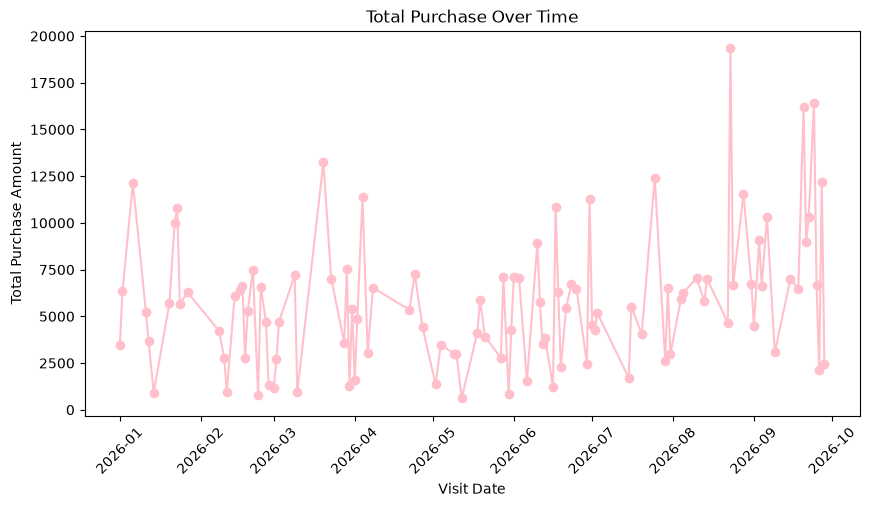

In [21]:
daily_purchase = df.groupby(
  "Visit_Date"
)["Purchase_Amount"].sum()



plt.figure(figsize=(10 , 5))

plt.plot(
  daily_purchase.index,
  daily_purchase.values,
  marker="o",
  color=("pink")
)

plt.title("Total Purchase Over Time")

plt.xlabel("Visit Date")
plt.ylabel("Total Purchase Amount")

plt.xticks(rotation=45)

plt.show()


#### 11. Use Seaborn:


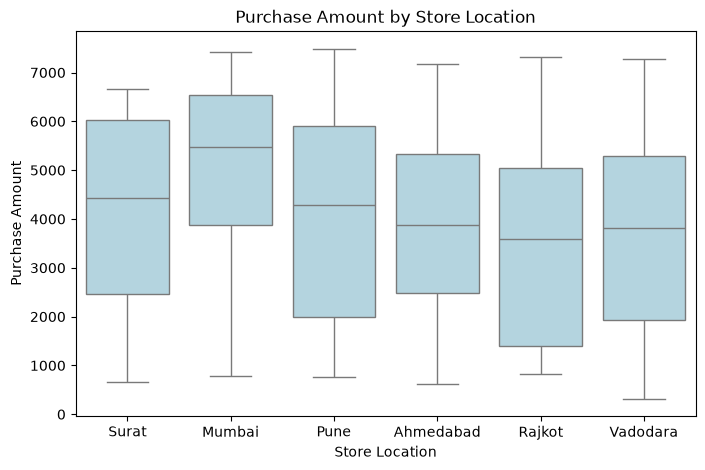

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Store_Location',
    y='Purchase_Amount',
    data=df,
    color="lightblue"
)

plt.title("Purchase Amount by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Purchase Amount")

plt.show()

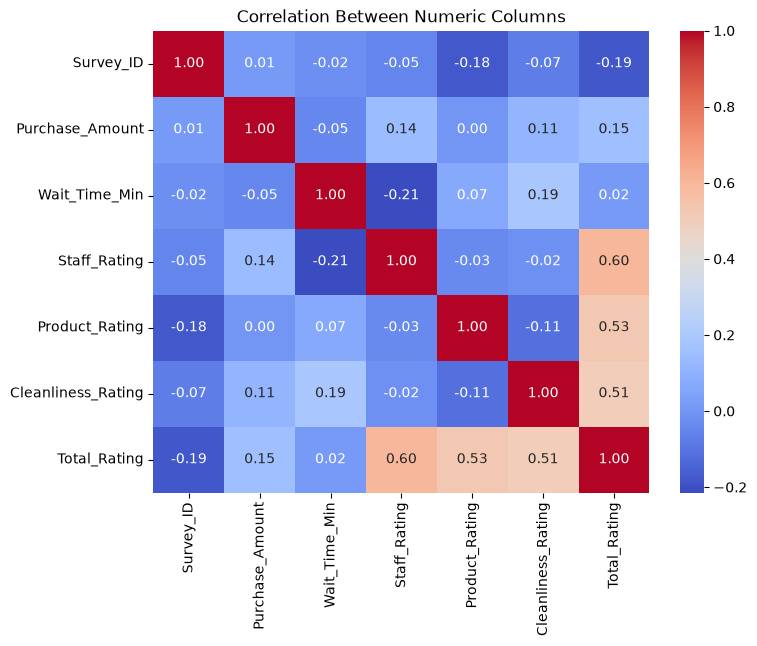

In [29]:
numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Numeric Columns")

plt.show()